In [1]:
# ===================================================================
# FLUORESCENT GREEN HEAT GRID
# ===================================================================

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle

CSV_PATH   = "metric2_beta.csv"
MAZE_DIR   = "mazes"
OUTPUT_DIR = "heatmaps_out"

def _norm_cols(df): return {c.lower(): c for c in df.columns}
def _require(df, cols):
    C = _norm_cols(df); miss = [x for x in cols if x not in C]
    if miss: raise ValueError(f"CSV missing columns: {miss}")

def _find_img(scene: str, level: str) -> str:
    bases = [f"{scene}_L{level}"]
    if level.lower().startswith("level"):
        n = level[5:]
        if n: bases += [f"{scene}_L{n}", f"{scene}_LLevel{n}"]
    for b in bases:
        for ext in ("png","jpg","jpeg","PNG","JPG","JPEG"):
            p = os.path.join(MAZE_DIR, f"{b}.{ext}")
            if os.path.isfile(p): return p
    raise FileNotFoundError(f"No maze image for {scene}/{level}. Tried: {bases}")

def _extent_preserving_image_aspect(xs, ys, img_shape,
                                    margin_ratio=0.05, min_span=6.0):
    x0, x1 = float(xs.min()), float(xs.max())
    y0, y1 = float(ys.min()), float(ys.max())
    dx = max(x1 - x0, min_span)
    dy = max(y1 - y0, min_span)
    h, w = img_shape[:2]
    aspect = w / h
    dx_adj = dx; dy_adj = dx_adj / aspect
    if dy_adj < dy:
        dy_adj = dy; dx_adj = dy_adj * aspect
    dx_adj *= (1 + margin_ratio); dy_adj *= (1 + margin_ratio)
    cx, cy = (x0+x1)/2, (y0+y1)/2
    return (cx - dx_adj/2, cx + dx_adj/2, cy - dy_adj/2, cy + dy_adj/2)

def _grid_bins_for_image(img_shape, base_cols=80):
    h, w = img_shape[:2]
    cols = base_cols
    rows = max(12, int(round(cols * (h / w))))
    return cols, rows

green_levels = [
    (0.9, 1.0, 0.9, 0.10),
    (0.75, 1.0, 0.75, 0.25),
    (0.5, 1.0, 0.5, 0.55),
    (0.2, 1.0, 0.3, 0.75),
    (0.0, 1.0, 0.0, 1.00),
]
cmap = ListedColormap(green_levels)
bounds = [0, 1, 2, 4, 8, 1e9]
norm = BoundaryNorm(bounds, cmap.N)

GRID_COLOR = "#ffffff"
GRID_ALPHA = 0.35
GRID_LW = 0.45

if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(f"'{CSV_PATH}' not found")

df = pd.read_csv(CSV_PATH)
_require(df, ["posx","posy","scenename","level","eventtype"])
C = _norm_cols(df)
df = df[df[C["eventtype"]].astype(str).str.lower()=="death"]
if df.empty: raise SystemExit("No rows with eventType=='Death'")

pairs = list(df[[C["scenename"],C["level"]]].astype(str)
             .drop_duplicates().itertuples(index=False,name=None))

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Rendering {len(pairs)} fluorescent green grids…")

for scene, level in pairs:
    d = df[(df[C["scenename"]].astype(str)==scene) &
           (df[C["level"]].astype(str)==level)]
    xs = d[C["posx"]].to_numpy(float)
    ys = d[C["posy"]].to_numpy(float)
    n = xs.size
    if n==0: continue

    img_path = _find_img(scene, level)
    img = imread(img_path)
    extent = _extent_preserving_image_aspect(xs, ys, img.shape)
    xmin, xmax, ymin, ymax = extent
    nx, ny = _grid_bins_for_image(img.shape, base_cols=80)

    H, xedges, yedges = np.histogram2d(xs, ys, bins=[nx, ny],
                                       range=[[xmin, xmax],[ymin, ymax]])
    H = H.T
    Hm = np.ma.masked_where(H==0, H)

    fig_w = 12
    fig_h = fig_w * (img.shape[0]/img.shape[1])
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    ax.imshow(np.flipud(img), extent=extent, origin="lower", zorder=0)

    # lighter translucent white overlay
    ax.add_patch(Rectangle((xmin, ymin), xmax-xmin, ymax-ymin,
                           facecolor=(1,1,1,0.30), edgecolor="none", zorder=1))

    ax.imshow(Hm, origin="lower", extent=extent, interpolation="nearest",
              cmap=cmap, norm=norm, alpha=0.95, zorder=2)

    ax.set_aspect('equal')
    ax.set_title(f"{scene} — {level} — Death Heat Grid (n={n})", fontsize=14)
    ax.set_axis_off()

    for xv in xedges:
        ax.plot([xv, xv], [ymin, ymax], color=GRID_COLOR, alpha=GRID_ALPHA, linewidth=GRID_LW, zorder=3)
    for yv in yedges:
        ax.plot([xmin, xmax], [yv, yv], color=GRID_COLOR, alpha=GRID_ALPHA, linewidth=GRID_LW, zorder=3)

    fig.tight_layout(pad=0)
    out_path = os.path.join(OUTPUT_DIR, f"heatgridGREEN_{scene}_L{level}__Death.png")
    fig.savefig(out_path, dpi=260, bbox_inches="tight", pad_inches=0)
    plt.close(fig)
    print(f"  ✓ {out_path}")

print("Done.")


Rendering 4 fluorescent green grids…
  ✓ heatmaps_out/heatgridGREEN_Main_LLevel1__Death.png
  ✓ heatmaps_out/heatgridGREEN_Level2_DarkMaze_LLevel2__Death.png
  ✓ heatmaps_out/heatgridGREEN_MainForLevel2_LLevel2__Death.png
  ✓ heatmaps_out/heatgridGREEN_MainForLevel3_LLevel3__Death.png
Done.


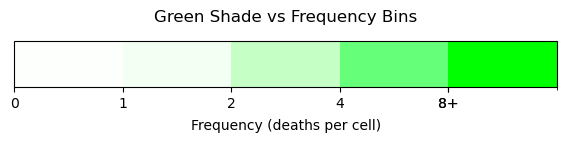

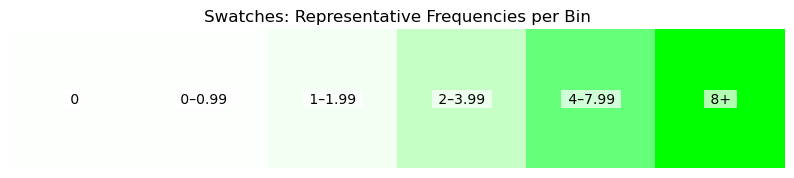

Bin mapping (left-closed, right-open; last bin is open-ended):
  Bin 0: freq in [0, 1) -> color RGBA=(0.95, 1.0, 0.95, 0.08)
  Bin 1: freq in [1, 2) -> color RGBA=(0.8, 1.0, 0.8, 0.25)
  Bin 2: freq in [2, 4) -> color RGBA=(0.55, 1.0, 0.55, 0.5)
  Bin 3: freq in [4, 8) -> color RGBA=(0.25, 1.0, 0.35, 0.8)
  Bin 4: freq in [8, ∞) -> color RGBA=(0.0, 1.0, 0.0, 1.0)


In [1]:
# ===================================================================
# Visual guide: Green shades vs. frequency bins
# Annotates which frequencies map to which shade
# ===================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

green_levels = [
    (0.95, 1.0, 0.95, 0.08),  # very faint mint
    (0.80, 1.0, 0.80, 0.25),  # soft lime
    (0.55, 1.0, 0.55, 0.50),  # mid green
    (0.25, 1.0, 0.35, 0.80),  # vivid bright
    (0.00, 1.0, 0.00, 1.00),  # neon green
]
bounds = [0, 1, 2, 4, 8, 1e9]

# -----------------------------------------------------------
cmap = ListedColormap(green_levels)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(7, 1.2))
fig.subplots_adjust(bottom=0.5)

cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=ax,
    orientation="horizontal",
    ticks=bounds[:-1] + [bounds[-2]] 
)
ticklabels = [str(b) for b in bounds[:-1]] + [f"{bounds[-2]}+"]
cb.set_ticklabels(ticklabels)
cb.set_label("Frequency (deaths per cell)", labelpad=6)
plt.title("Green Shade vs Frequency Bins", pad=14)
plt.show()

sample_vals = [
    0.0,      
    0.5,      
    1.5,      
    3.0,      
    6.0,      
    10.0      
]
labels = ["0", "0–0.99", "1–1.99", "2–3.99", "4–7.99", "8+"]

swatch = np.array(sample_vals)[None, :]  # 1 x N

plt.figure(figsize=(10, 1.8))
plt.imshow(swatch, aspect="auto", cmap=cmap, norm=norm)
plt.gca().set_axis_off()
for i, txt in enumerate(labels):
    plt.text(i, 0, f" {txt} ", ha="center", va="center", fontsize=10,
             color="black", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5))
plt.title("Swatches: Representative Frequencies per Bin")
plt.show()

print("Bin mapping (left-closed, right-open; last bin is open-ended):")
for i in range(len(bounds)-1):
    lo, hi = bounds[i], bounds[i+1]
    rng = f"[{lo}, {hi})" if i < len(bounds)-2 else f"[{lo}, ∞)"
    rgba = green_levels[i]
    print(f"  Bin {i}: freq in {rng} -> color RGBA={rgba}")
